In [7]:
df.to_csv('hotel_final.csv',index=False)

## **Analysis and Findings:** 


Detailed presentation of the analysis conducted, including visualizations, and the insights derived from this analysis.

In [1]:
### Exploratory Analysis

In [1]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# load data
df = pd.read_csv('file.csv')

In [13]:
# view data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,booking_date
0,Resort Hotel,0,7 days,2015,7,27,1,0,1,1,...,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-06-24
1,Resort Hotel,0,13 days,2015,7,27,1,0,1,1,...,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,2015-06-18
2,Resort Hotel,0,14 days,2015,7,27,1,0,2,2,...,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,2015-06-17
3,Resort Hotel,0,0 days,2015,7,27,1,0,2,2,...,No Deposit,0,Transient,107.0,0,0,Check-Out,2015-07-03,2015-07-01,2015-07-01
4,Resort Hotel,0,9 days,2015,7,27,1,0,2,2,...,No Deposit,0,Transient,103.0,0,1,Check-Out,2015-07-03,2015-07-01,2015-06-22


In [10]:
# we move straight to analysis
#we performed Exploratory Data Analysis to uncover patterns and insights within the dataset. Key analyses include:

In [11]:
# Basic Statistics

In [52]:
# total customers who booked
print('Total Customer')
print(df.shape[0])

print('\n')
# total cuatomers who booked at each hotel
print('Total Customers by hotel')
print(df.groupby('hotel')['hotel'].count())

print('\n')
# percentage at each hotel
print('Percent of custoers by hotel')
print(df['hotel'].value_counts(normalize=True))

Total Customer
84926


Total Customers by hotel
hotel
City Hotel      52098
Resort Hotel    32828
Name: hotel, dtype: int64


Percent of custoers by hotel
City Hotel      0.613452
Resort Hotel    0.386548
Name: hotel, dtype: float64


In [45]:
# total cancellatons

# filter for canceled data onlt
cancelled = df[df['is_canceled']==1]

# the total cancellation
print('Total Cancellation')
print(cancelled.shape[0])

print('\n')
# total cancellatons by hotel
print('Total Cancellation by Hotel')
print(cancelled.groupby('hotel')['is_canceled'].sum())

print('\n')
# percent of cancellations by hotel
print('Percent of cancellation by hotel')
print(cancelled['hotel'].value_counts(normalize=True))

Total Cancellation
23726


Total Cancellation by Hotel
hotel
City Hotel      15854
Resort Hotel     7872
Name: is_canceled, dtype: int64


Percent of cancellation by hotel
City Hotel      0.668212
Resort Hotel    0.331788
Name: hotel, dtype: float64


In [55]:
# Total Adr
print('Total adr')
print(df['adr'].sum())

print('\n')
# total adr of the two hotels
print('total adr by hotel')
print(df.groupby('hotel')['adr'].sum())

Total adr
9240069.969999999


total adr by hotel
hotel
City Hotel      5904242.56
Resort Hotel    3335827.41
Name: adr, dtype: float64


In [133]:
# group customers by repeated or not
df.groupby('is_repeated_guest')['hotel'].value_counts(normalize=True)
# mosst of the customers booking are are first time customers

is_repeated_guest  hotel       
0                  City Hotel      0.618868
                   Resort Hotel    0.381132
1                  Resort Hotel    0.538937
                   City Hotel      0.461063
Name: hotel, dtype: float64

In [131]:
df[df['is_repeated_guest']==0]['hotel'].value_counts(normalize=True)

City Hotel      0.618868
Resort Hotel    0.381132
Name: hotel, dtype: float64

In [59]:
# Repeat guest by hotel

# filter for repeated guestdata 
repeat = df[df['is_repeated_guest']==1]

# total repeat guest
print('Total repeat guest')
print(repeat.shape[0])

print('\n')
# repeat guest by hotel
print('Repeat guest by hotel')
print(repeat.groupby('hotel')['is_repeated_guest'].sum())

Total repeat guest
2915


Repeat guest by hotel
hotel
City Hotel      1344
Resort Hotel    1571
Name: is_repeated_guest, dtype: int64


In [4]:
# Set color palette
palette = {"City Hotel": "#87CEEB", "Resort Hotel": "#3CB371"}

In [64]:
# Data Profiling
# profile the data, checking for missing values, outliers, and inconsistencies. -- done this in data validation and cleaning

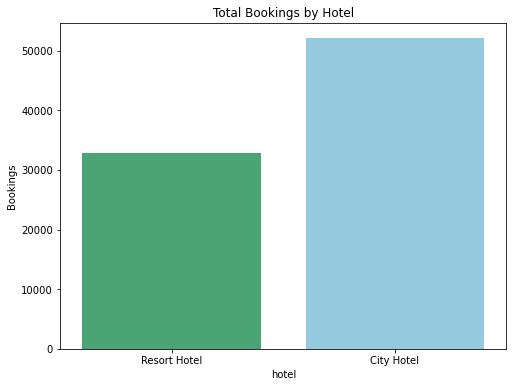

In [233]:
# total booking by hotel
plt.figure(figsize=(8,6))
sns.countplot(x='hotel',data=df, palette=palette)
plt.ylabel('Bookings')
plt.title('Total Bookings by Hotel')
sns.set_palette("icefire")

In [187]:
# booking trends over time
#Created a line chart to visualize the number of bookings over different time periods (monthly, weekly).

In [4]:
# create arrival_date column

# Convert month names to numbers 
month_mapping = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

# Replace month names with their corresponding numbers
df['arrival_date_month'] = df['arrival_date_month'].replace(month_mapping).astype(int)

# Create arrival date column
df['arrival_date'] = df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month'].astype(str) + '-' + df['arrival_date_day_of_month'].astype(str)

# arrival date column to date time format
df['arrival_date'] = pd.to_datetime(df['arrival_date'])

In [5]:
# create booking date from lead time and arrival date. booking = arrival - lead time
df['lead_time'] = pd.to_timedelta(df['lead_time'], unit='D')  # Convert lead time from days to timedelta
df['booking_date'] = df['arrival_date'] - df['lead_time']

In [152]:
# year over year trend - 
#Compare booking volumes over the years to identify growth patterns or declines.

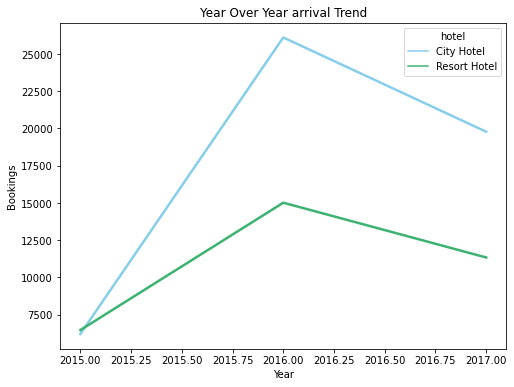

In [22]:
# aggregate data
booking_year = df.groupby(['arrival_date_year', 'hotel'], as_index=False)['is_canceled'].count()

# yearly trend by hotel
plt.figure(figsize=(8,6))
sns.lineplot(x='arrival_date_year',y='is_canceled',data=booking_year, hue='hotel', linewidth=2.5, palette=palette)
plt.ylabel('Bookings')
plt.xlabel('Year')
plt.title('Year Over Year arrival Trend')
sns.set_palette("icefire")

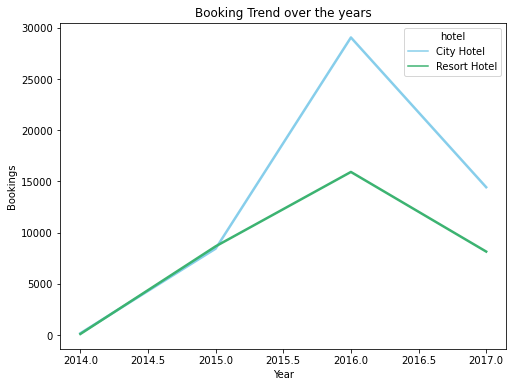

In [17]:
# create book year
df['book_year'] = df['booking_date'].dt.year
# aggregate data
booking_year = df.groupby(['book_year', 'hotel'], as_index=False)['is_canceled'].count()

# yearly trend by hotel
plt.figure(figsize=(8,6))
sns.lineplot(x='book_year',y='is_canceled',data=booking_year, hue='hotel', linewidth=2.5, palette=palette)
plt.ylabel('Bookings')
plt.xlabel('Year')
plt.title('Booking Trend over the years')
sns.set_palette("icefire")

There increase in the year 2016 compared to the previois year 2015. An a decline in 2017 following the peak in 2016

In [176]:
# seasonal trend -explore how bookings vary month to month 
#(or across different seasons- will have to create column for season)

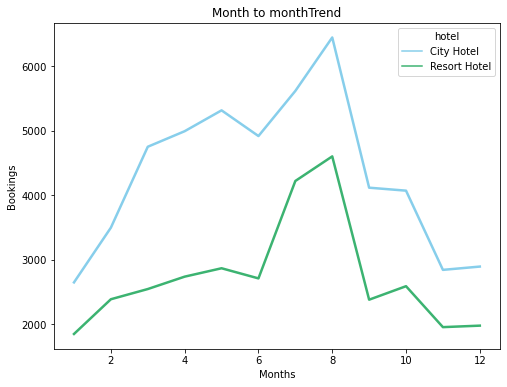

In [23]:
# aggregate data
booking_month = df.groupby(['arrival_date_month', 'hotel'], as_index=False)['is_canceled'].count()

# MOnthly trend by hotel
plt.figure(figsize=(8,6))
sns.lineplot(x='arrival_date_month',y='is_canceled',data=booking_month,hue='hotel', linewidth=2.5, palette=palette)
plt.ylabel('Bookings')
plt.xlabel('Months')
plt.title('Month to monthTrend')
sns.set_palette("icefire")

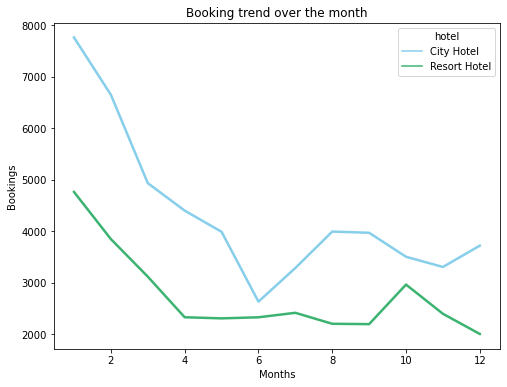

In [20]:
# create book month
df['book_month'] = df['booking_date'].dt.month
# aggregate data
booking_month = df.groupby(['book_month', 'hotel'], as_index=False)['is_canceled'].count()

# MOnthly trend by hotel
plt.figure(figsize=(8,6))
sns.lineplot(x='book_month',y='is_canceled',data=booking_month,hue='hotel', linewidth=2.5, palette=palette)
plt.ylabel('Bookings')
plt.xlabel('Months')
plt.title('Booking trend over the month')
sns.set_palette("icefire")

We can see an increase in bookings from the 6th to the 8th month i.e june, july, august are peak months. From the october there is a steady decline probably beacuse of the winter season. after we begin to see a peak .

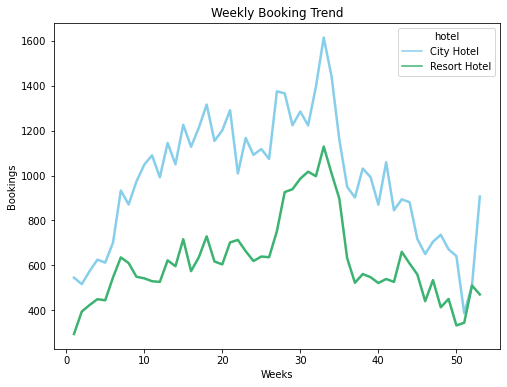

In [236]:
# weekly boooking trends
# aggregate data
booking_week = df.groupby(['arrival_date_week_number', 'hotel'], as_index=False)['is_canceled'].count()

# MOnthly trend by hotel
plt.figure(figsize=(8,6))
sns.lineplot(x='arrival_date_week_number',y='is_canceled',data=booking_week, hue='hotel', linewidth=2.5, palette=palette)
plt.ylabel('Bookings')
plt.xlabel('Weeks')
plt.title('Weekly Booking Trend')
sns.set_palette("icefire")

This tells the same information as the monthly booking trend

In [240]:
# Cancellation Analysis

Text(0.5, 1.0, 'Cancellation Count by Hotel')

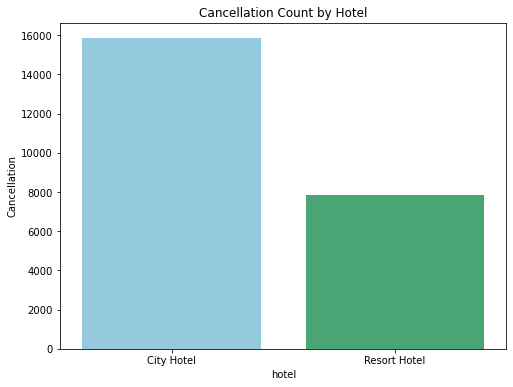

In [244]:
# Cancellation between hotels
# aggregate data
cancel = df.groupby('hotel',as_index=False)['is_canceled'].sum()
# plot graph
plt.figure(figsize=(8,6))
sns.barplot(x='hotel',y='is_canceled',data=cancel, palette=palette)
plt.ylabel('Cancellation')
plt.title('Cancellation Count by Hotel')

In [ ]:
# Assuming 'is_canceled' is a column where 1 represents a canceled booking and 0 represents a non-canceled booking
df['total_booking'] = 1  # Create a column to count all bookings
summary1 = df.groupby('hotel', as_index=False).agg(total_bookings=('total_booking', 'sum'),
                                                  canceled=('is_canceled', 'sum'))


In [245]:
summary2 = df.groupby('hotel', as_index=False).agg(
    total_bookings=('hotel', 'size'),  # Count the number of rows for each hotel
    canceled=('is_canceled', 'sum')    # Sum the 'is_canceled' column to get total cancellations
)


In [ ]:
# Total Bookings and TotalCancellation by Hotels


In [246]:
summary2

,hotel,total_bookings,canceled
0,City Hotel,52098,15854
1,Resort Hotel,32828,7872


KeyError: 'total_cancellations'

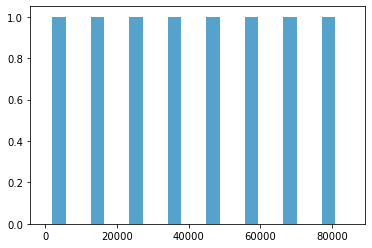

In [331]:
# Setting the positions and width for the bars
positions = range(len(df['hotel']))
width = 0.35  # the width of the bars

df['total_bookings'] =1
fig, ax = plt.subplots()
# Plotting total bookings
bookings_bars = ax.bar(positions, df['total_bookings'], width, label='Total Bookings')

# Plotting total cancellations, with the bar positions offset by the width of the bar
cancellations_bars = ax.bar([p + width for p in positions], df['total_cancellations'], width, label='Total Cancellations')

# Adding labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Hotel')
ax.set_ylabel('Number of Bookings')
ax.set_title('Total Bookings vs Total Cancellations by Hotel')
ax.set_xticks([p + width / 2 for p in positions])
ax.set_xticklabels(df['hotel'])
ax.legend()

# Adding labels above the bars for clarity
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{}'.format(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bookings_bars)
add_labels(cancellations_bars)

plt.show()


In [251]:
# geographical analysis - pattern in booking behaviour and cancellation rate

Text(0.5, 1.0, 'Top 10 Country by Bookings and Hotel')

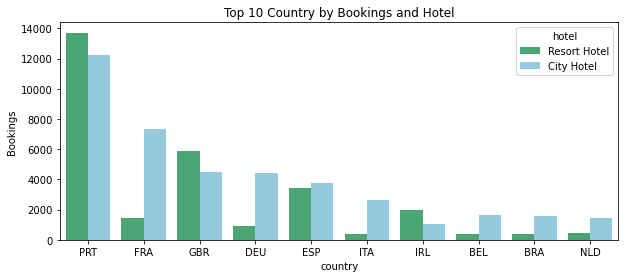

In [25]:
# top country with most bookings by hotel
#aggregate bookings by country
country = df.groupby('country',as_index=False)['is_canceled'].count()

# sort by bookings to get top 15
top_country = country.sort_values(by='is_canceled',ascending=False).head(10)

# filter df for countries in top country
filter = df[df['country'].isin(top_country['country'])]

# aggregate bookings by country and hotel
filter_group = filter.groupby(['country','hotel'],as_index=False)['is_canceled'].count()

# sort filter group
filter_group_sort = filter_group.sort_values(by='is_canceled',ascending=False)


# plot graph
plt.figure(figsize=(10,4))
sns.barplot(x='country',y='is_canceled',data=filter_group_sort,hue='hotel',palette=palette)
plt.ylabel('Bookings')
plt.title('Top 10 Country by Bookings and Hotel')

This graph is not shoiwng the countries in the order of ranking.

Text(0.5, 1.0, 'Top 15 Country by Cancellations and Hotel')

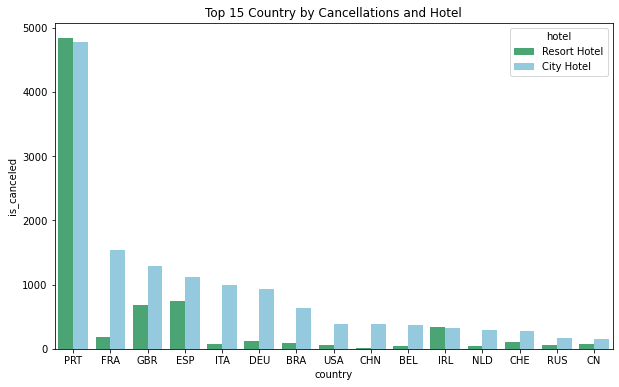

In [293]:
# top countries with most cancellation by hotel
#aggregate cancellation by country
country1 = df.groupby('country',as_index=False)['is_canceled'].sum()

# sort by cancellation to get top 15
top_country1 = country1.sort_values(by='is_canceled',ascending=False).head(15)

# filter df for countries in top country
filter1 = df[df['country'].isin(top_country1['country'])]

# aggregate bookings by country and hotel
filter_group1 = filter1.groupby(['country','hotel'],as_index=False)['is_canceled'].sum()

# sort filter group
filter_group_sort1 = filter_group1.sort_values(by='is_canceled',ascending=False)

# plot graph
plt.figure(figsize=(10,6))
sns.barplot(x='country',y='is_canceled',data=filter_group_sort1,hue='hotel',palette=palette)
#plt.ylabel('Cancellation')
plt.title('Top 15 Country by Cancellations and Hotel')

To make more insight calculate cancellation rate of top countries to know which country cancellss faster than they book.

In [281]:
# Deposit Analysis
# Get the prorportion of bookings involving a deposit and variations across hotel types

          hotel deposit_type  is_canceled
0    City Hotel   No Deposit        51240
1    City Hotel   Non Refund          843
2    City Hotel   Refundable           15
3  Resort Hotel   No Deposit        32543
4  Resort Hotel   Non Refund          193
5  Resort Hotel   Refundable           92


Text(0.5, 1.0, 'Deposit Types by Hotel')

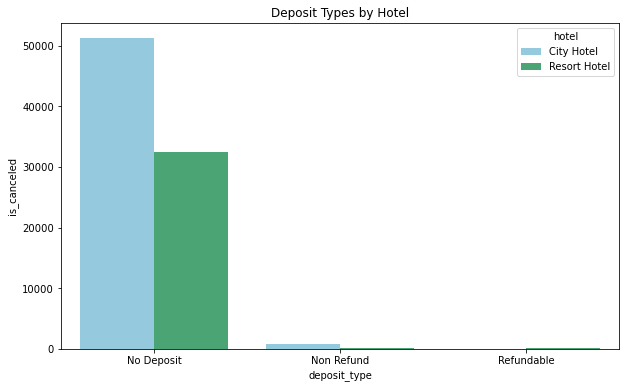

In [292]:
# Analysis of Deposit type by Hotel
# aggregate data
deposit = df.groupby(['hotel','deposit_type'],as_index=False)['is_canceled'].count()
print(deposit)

# plot graph
plt.figure(figsize=(10,6))
sns.barplot(x='deposit_type',y='is_canceled',data=deposit,hue='hotel',palette=palette)
#plt.ylabel("Bookings")
plt.title('Deposit Types by Hotel')

In [41]:
# Are there differences in cancellation rates between bookings with and without a deposit? -   

In [ ]:
# customer behaviour
# Are there specific customer types associated with higher or lower booking changes? -

Text(0.5, 0, 'Bookings')

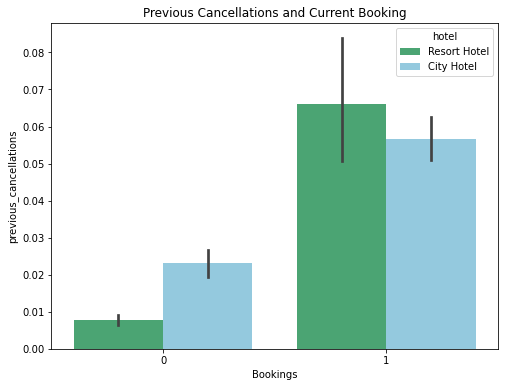

In [301]:
# previous cancellation and impact in current booking
plt.figure(figsize=(8,6))
sns.barplot(x='is_canceled',y='previous_cancellations',data=df,hue='hotel',palette=palette)
plt.title('Previous Cancellations and Current Booking')
plt.xlabel('Bookings')

Text(0.5, 0, 'Bookings')

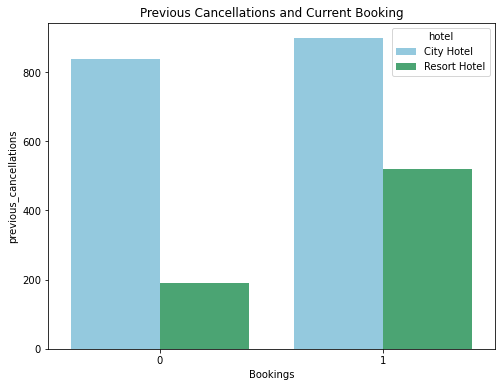

In [312]:
# aggregating by summing
previous = df.groupby(['hotel','is_canceled'],as_index=False)['previous_cancellations'].sum()

# previous cancellation and impact in current booking
plt.figure(figsize=(8,6))
sns.barplot(x='is_canceled',y='previous_cancellations',data=previous,hue='hotel',palette=palette)
plt.title('Previous Cancellations and Current Booking')
plt.xlabel('Bookings')

In [ ]:
# you can analyze this data to determine if there's a correlation between the number of previous cancellations and the
#likelihood of future cancellations.


In [26]:
#Statistical Analysis

# Correlation Coefficient: Calculate the Pearson correlation coefficient between the number of
#previous cancellations and the current cancellation status (`is_canceled`). This will give you an immediate sense of 
#any linear relationship.


correlation = df['previous_cancellations'].corr(df['is_canceled'])
print("Correlation coefficient:", correlation)

Correlation coefficient: 0.05277854770566711


In [27]:
#Group Statistics 
#You could also group the data by the number of previous cancellations and calculate the cancellation rate for each group.

grouped_data = df.groupby('previous_cancellations',as_index=False).agg(
    cancellation_rate=pd.NamedAgg(column='is_canceled', aggfunc='mean'),
    count=pd.NamedAgg(column='is_canceled', aggfunc='size')
)
grouped_data


,previous_cancellations,cancellation_rate,count
0,0,0.271421,83354
1,1,0.771237,1342
2,2,0.344444,90
3,3,0.277778,54
4,4,0.250000,16
5,5,0.142857,14
6,6,0.117647,17
7,11,0.074074,27
8,13,0.750000,4
9,14,1.000000,1


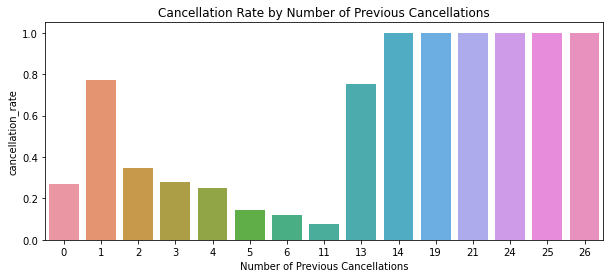

In [28]:
# bar plot for previous cancellation and current cancelation
# Show the cancellation rate by the number of previous cancellations.

plt.figure(figsize=(10, 4))
sns.barplot(x=grouped_data['previous_cancellations'], y=grouped_data['cancellation_rate'])
plt.title('Cancellation Rate by Number of Previous Cancellations')
plt.xlabel('Number of Previous Cancellations')
#plt.ylabel('Cancellation Rate')
plt.show()

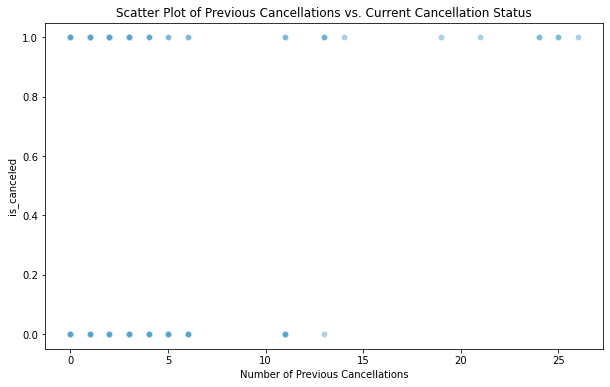

In [328]:
# sactter plot 
# For a large dataset with many unique values in `previous_cancellations`, a
#scatter plot can help visualize the correlation more clearly.

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['previous_cancellations'], y=df['is_canceled'], alpha=0.5)
plt.title('Scatter Plot of Previous Cancellations vs. Current Cancellation Status')
plt.xlabel('Number of Previous Cancellations')
#plt.ylabel('Is Canceled (0 or 1)')
plt.show()

In [ ]:
# Room Allocation And Changes
# Analyzed how often guests receive the room type they initially reserved.

Text(0.5, 1.0, 'Adr by Hotel')

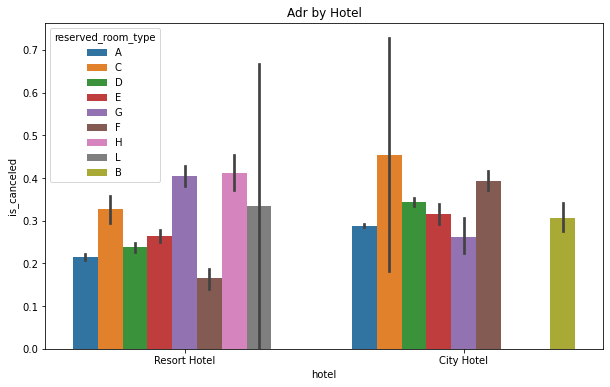

In [9]:
# most popular rooms by hotel
plt.figure(figsize=(10, 6))
sns.barplot(x='hotel',y='is_canceled',data=df,hue='reserved_room_type')
plt.title('Popular Room Type by hotel')

Text(0.5, 1.0, 'Popular Room Type by hotel')

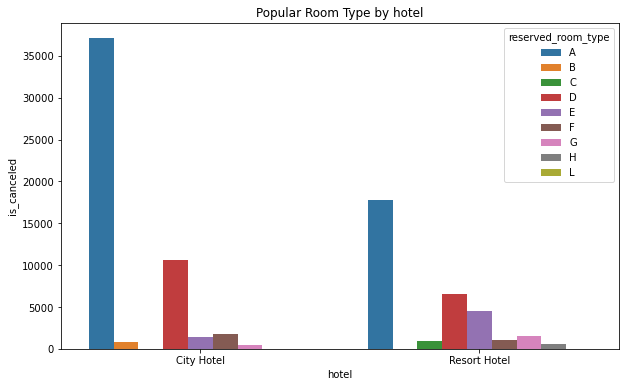

In [11]:
# What is the most commonly reserved room type, and how does it vary between hotels?
# Most popular room by hotel
room = df.groupby(['hotel','reserved_room_type'],as_index=False)['is_canceled'].count()
plt.figure(figsize=(10, 6))
sns.barplot(x='hotel',y='is_canceled',data=room,hue='reserved_room_type')
plt.title('Popular Room Type by hotel')

In [ ]:
#Average Daily Rate (ADR) Analysis
#Investigated how ADR varies across different customer demographics.

Text(0.5, 1.0, 'Adr by Hotel')

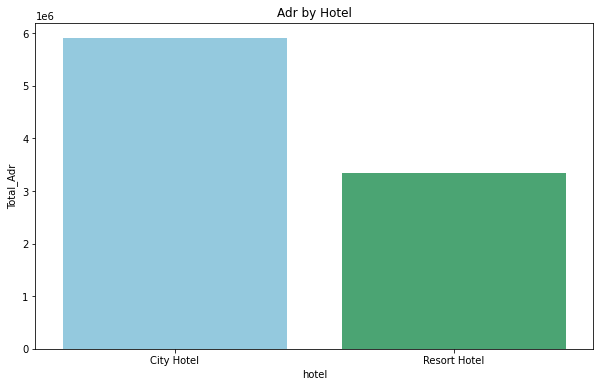

In [344]:
# Total Adr by Hotel
adr_group = df.groupby('hotel',as_index=False).agg(
    Total_Adr=pd.NamedAgg(column='adr', aggfunc='sum')
)
# visualizing information
plt.figure(figsize=(10, 6))
sns.barplot(x='hotel',y='Total_Adr',data=adr_group,palette=palette)
plt.title('Adr by Hotel')

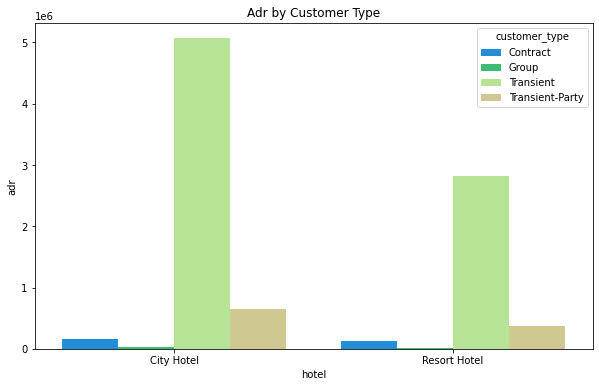

In [352]:
# Adr by customer type 
adr_customer = df.groupby(['hotel','customer_type'],as_index=False)['adr'].sum()
# visualise information
plt.figure(figsize=(10, 6))
sns.barplot(x='hotel',y='adr',data=adr_customer,hue='customer_type')
plt.title('Adr by Customer Type')
sns.set_palette('inferno')

Text(0.5, 1.0, 'Adr by Distribution Channel')

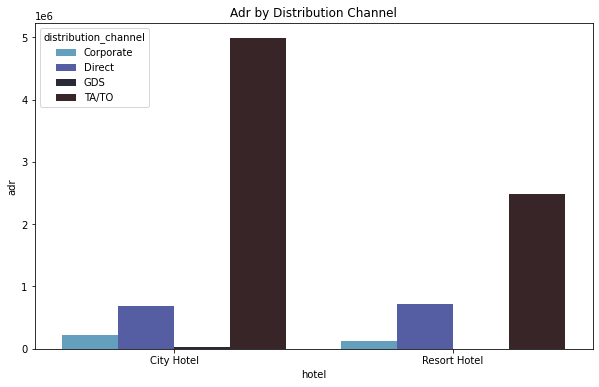

In [36]:
# Adr by distribution channel
# aggregate data
adr_dist = df.groupby(['hotel','distribution_channel'],as_index=False)['adr'].sum()
# visualise information
plt.figure(figsize=(10, 6))
sns.barplot(x='hotel',y='adr',data=adr_dist,hue='distribution_channel')
plt.title('Adr by Distribution Channel')
#sns.set_palette('inferno')

In [359]:
# Booking by Market Segment

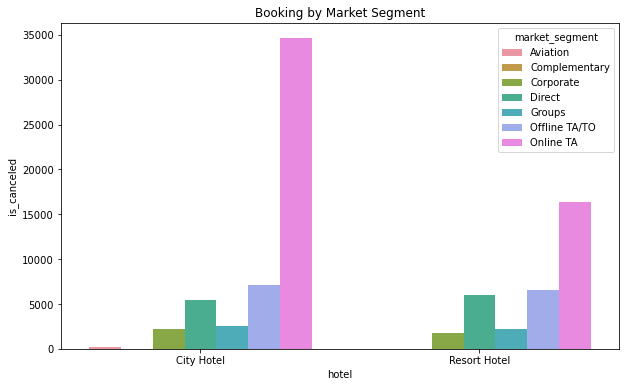

In [360]:
# what market segment contribute most to booking by hotel
booking_market = df.groupby(['hotel','market_segment'],as_index=False)['is_canceled'].count()
# visulaize
plt.figure(figsize=(10, 6))
sns.barplot(x='hotel',y='is_canceled',data=booking_market,hue='market_segment')
plt.title('Booking by Market Segment')
sns.set_palette('winter')

In [361]:
# Lead time and Cancellation

In [14]:
#Statistical Analysis

# Correlation Coefficient: Calculate the Pearson correlation coefficient between the number of
#lead time and the current cancellation status (`is_canceled`). This will give you an immediate sense of 
#any linear relationship.

# convert lead time to integer
df['lead_time']  = df['lead_time'].astype(int)

correlation = df['lead_time'].corr(df['is_canceled'])
print("Correlation coefficient:", correlation)

Correlation coefficient: 0.1812752067177567


In [15]:
#Group Statistics 
#You could also group the data by the number and calculate the cancellation rate for each group.

grouped_lead = df.groupby('lead_time',as_index=False).agg(
    cancellation_rate=pd.NamedAgg(column='is_canceled', aggfunc='mean'),
    count=pd.NamedAgg(column='is_canceled', aggfunc='size')
)
grouped_lead


,lead_time,cancellation_rate,count
0,0,0.058625,5339
1,1,0.064787,2979
2,2,0.095762,1817
3,3,0.100742,1618
4,4,0.096038,1489
...,...,...,...
473,615,1.000000,2
474,622,1.000000,2
475,626,1.000000,1
476,629,1.000000,2


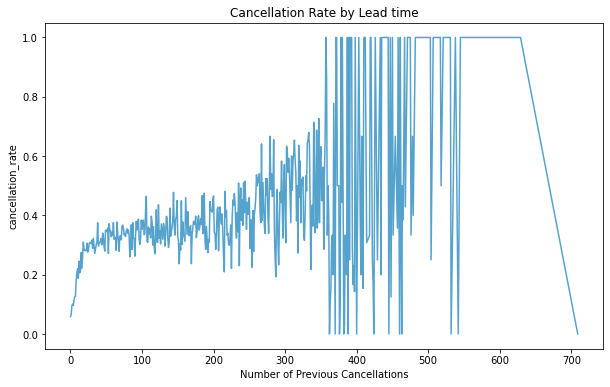

In [34]:
# bar plot for previous cancellation and current cancelation
# Show the cancellation rate by the number of previous cancellations.

plt.figure(figsize=(10, 6))
sns.lineplot(x=grouped_lead['lead_time'], y=grouped_lead['cancellation_rate'])
plt.title('Cancellation Rate by Lead time')
plt.xlabel('Number of Previous Cancellations')
#plt.ylabel('Cancellation Rate')
plt.show()

Will have to analyse lengthof lead time and cancellation rate later

In [19]:
# Performance Metrics

Text(0.5, 1.0, 'Avg lead time by hotels')

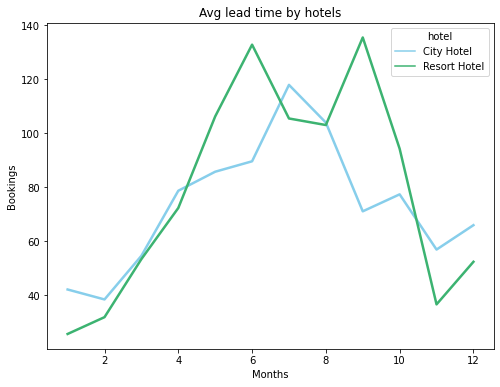

In [34]:
# What are the average lead times for bookings? per month by hotel
# aggregate data
avg_lead = df.groupby(['hotel','arrival_date_month'],as_index=False)['lead_time'].mean()
# plot data
plt.figure(figsize=(8,6))
sns.lineplot(x='arrival_date_month',y='lead_time',data=avg_lead, hue='hotel', linewidth=2.5, palette=palette)
plt.ylabel('Bookings')
plt.xlabel('Months')
plt.title('Avg lead time by hotels')

In [39]:
# What is the average number of special requests made by guests by hotels
avg_request = df.groupby('hotel',as_index=False)['total_of_special_requests'].mean()
avg_request

,hotel,total_of_special_requests
0,City Hotel,0.709778
1,Resort Hotel,0.684507


Text(0.5, 1.0, 'Adr Vs Lead Time by hotels')

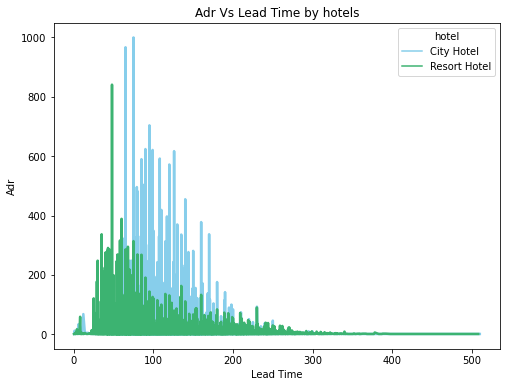

In [44]:
# Is there a correlation between lead time and the average daily rate (ADR)?
# aggregate data
lead_adr = df.groupby(['hotel','adr'],as_index=False)['lead_time'].count()
# plot data
plt.figure(figsize=(8,6))
sns.lineplot(x='adr',y='lead_time',data=lead_adr, hue='hotel', linewidth=2.5, palette=palette)
plt.ylabel('Adr')
plt.xlabel('Lead Time')
plt.title('Adr Vs Lead Time by hotels')

In [ ]:
#Lead Time Analysis:** - How does lead time vary across different types of reservations (canceled vs. not canceled, hotel types, etc.)?


In [ ]:
# **Room Type Insights:**- Do guests who receive a different assigned room type than reserved exhibit different behavior?


In [ ]:
# **Waiting List Analysis:** How often are reservations placed on the waiting list, and what factors contribute to a reservation being moved from the waiting list to confirmation?
   #- Is there a correlation between waiting list duration and cancellation rates?


In [ ]:
#These three analysis above that are yet to be done will be properly and further analysed

## My Findings and Insights


### Introduction
This section explores the dynamic patterns of hotel bookings, cancellation rates, and guest preferences over various periods and demographics. The insights derived from a comprehensive suite of visualizations help to understand factors influencing customer behavior and hotel performance, aiming to optimize operational and marketing strategies.


## Booking Trends by Hotel

Figure 1: The bar chart comparing total bookings between City Hotel and Resort Hotel clearly illustrates that City Hotel has secured more bookings than Resort Hotel. This visualization effectively highlights the disparity in guest preference or demand between the two establishments.

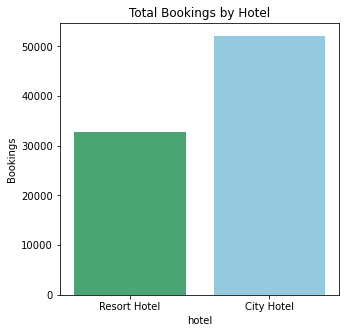

In [6]:
# total booking by hotel
plt.figure(figsize=(5,5))
sns.countplot(x='hotel',data=df, palette=palette)
plt.ylabel('Bookings')
plt.title('Total Bookings by Hotel')
sns.set_palette("icefire")

### Booking Trends Over Time
**Figure 1: Monthly Booking Trends**
The line chart (Figure 1) below reveals the fluctuation in the number of bookings per month throughout the years. A significant peak is observed in August, with over 6000 bookings for city hotl and 4601 boookings for Resort Hotel, corresponding with the summer vacation season. Conversely, the lowest booking month is November, with under 100 bookings, indicating a possible off-peak season for the hotels. This pattern suggests a strong seasonal influence on booking behavior, crucial for planning promotions and staffing.


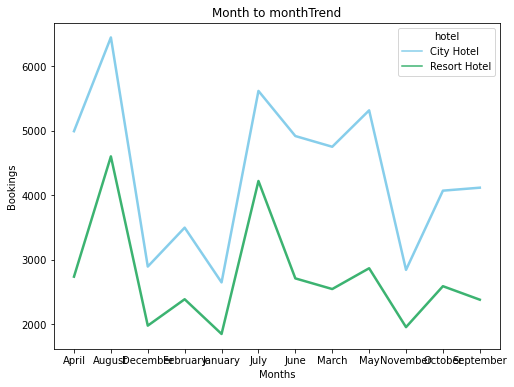

In [12]:
# aggregate data
booking_month = df.groupby(['arrival_date_month', 'hotel'], as_index=False)['is_canceled'].count()

# MOnthly trend by hotel
plt.figure(figsize=(8,6))
sns.lineplot(x='arrival_date_month',y='is_canceled',data=booking_month,hue='hotel', linewidth=2.5, palette=palette)
plt.ylabel('Bookings')
plt.xlabel('Months')
plt.title('Month to monthTrend')
sns.set_palette("icefire")

### Cancellation Rates by hotel

"The pie chart illustrates the cancellation rates between two hotels, with City Hotel cancellation rate being nearly double that of Resort Hotel. This stark contrast highlights significant differences in cancellation behaviors at each location."

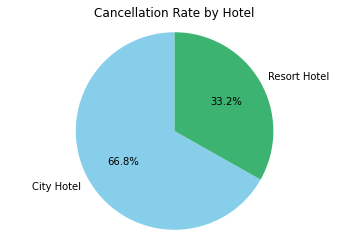

In [98]:
## cancellation rate by hotel

# Aggregate data
summary2 = df.groupby('hotel', as_index=False).agg(
    total_bookings=('hotel', 'size'),  # Count the number of rows for each hotel
    canceled=('is_canceled', 'sum')    # Sum the 'is_canceled' column to get total cancellations
)

custom_colors = ['#87CEEB', '#3CB371']
#palette = {"City Hotel": "#87CEEB", "Resort Hotel": "#3CB371"}
# create pie chart
# Plotting the pie chart using Matplotlib
fig, ax = plt.subplots()
ax.pie(summary2['canceled'], labels=summary2['hotel'], autopct='%1.1f%%', startangle=90, colors=custom_colors)
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Cancellation Rate by Hotel')
plt.show()


### Cancellation Rates by Lead Time
**Figure 2: Cancellation Rates as a Function of Lead Time**
Figure 2 presents a scatter plot that maps cancellation rates against lead times. There is a discernible trend where longer lead times are associated with higher cancellation rates. Specifically, bookings made more than 100 days in advance tends to result in cancellation. This finding could inform cancellation policy adjustments to mitigate loss from early bookings

A direct relationship between cancellation rates and lead times has been established, indicating potential revenue losses with longer lead times..


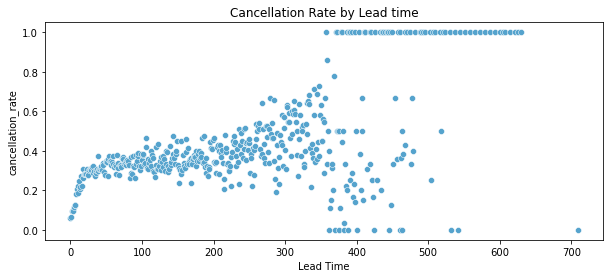

In [16]:
# Show the cancellation rate by lead time
plt.figure(figsize=(10, 4))
sns.scatterplot(x=grouped_lead['lead_time'], y=grouped_lead['cancellation_rate'])
plt.title('Cancellation Rate by Lead time')
plt.xlabel('Lead Time')
#plt.ylabel('Cancellation Rate')
plt.show()

## Cancellation Rate by Number of Previous Cancellation

**Figure 3: Cancellation rate by previous cancellation** The chart shows a bar chart that highlights the relationship between previous cancellations and cancellation rates. The findings indicate a clear trend: a higher number of previous cancellations correlates with increased future cancellations. This pattern indicates a high risk of repeat cancellations among guests who have canceled before. Interestingly, even guests who had only one previous cancellation exhibited a significantly elevated cancellation rate. This suggests that identifying guests with any cancellation history could be key to reducing future cancellations."

In [20]:
# bar plot for previous cancellation and current cancelation
# Show the cancellation rate by the number of previous cancellations.

plt.figure(figsize=(8, 6))
sns.barplot(x=grouped_data['previous_cancellations'], y=grouped_data['cancellation_rate'])
plt.title('Cancellation Rate by Number of Previous Cancellations')
plt.xlabel('Number of Previous Cancellations')
#plt.ylabel('Cancellation Rate')
plt.show()

NameError: name 'grouped_data' is not defined

<Figure size 576x432 with 0 Axes>

### Guest Geographical Distribution
**Figure 3: Geographic Analysis of Guest Origins**
This bar chart illustrates the top 10 countries from which the majority of guests originate. The Portugal and France lead, highlighting the local and regional market's importance. Understanding these geographical patterns helps tailor marketing campaigns to specific demographic segments.


Text(0.5, 1.0, 'Top 10 Country by Bookings and Hotel')

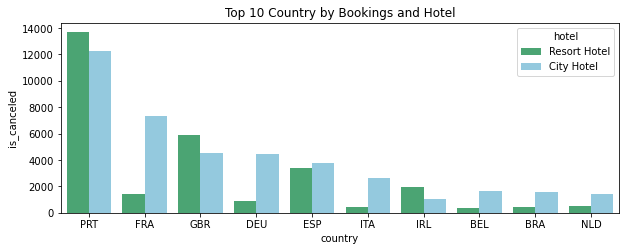

In [31]:
# top country with most bookings by hotel
#aggregate bookings by country
country = df.groupby('country',as_index=False)['is_canceled'].count()

# sort by bookings to get top 15
top_country = country.sort_values(by='is_canceled',ascending=False).head(10)

# filter df for countries in top country
filter = df[df['country'].isin(top_country['country'])]

# aggregate bookings by country and hotel
filter_group = filter.groupby(['country','hotel'],as_index=False)['is_canceled'].count()

# sort filter group
filter_group_sort = filter_group.sort_values(by='is_canceled',ascending=False)


# plot graph
plt.figure(figsize=(10,3.5))
sns.barplot(x='country',y='is_canceled',data=filter_group_sort,hue='hotel',palette=palette)
#plt.ylabel('Bookings')
plt.title('Top 10 Country by Bookings and Hotel')

In [79]:
## booking by market segments

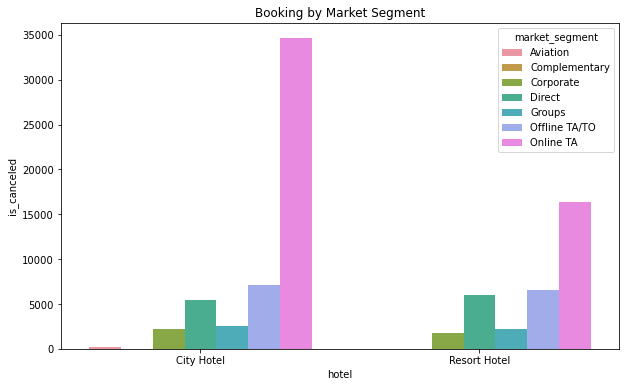

In [80]:
# what market segment contribute most to booking by hotel
booking_market = df.groupby(['hotel','market_segment'],as_index=False)['is_canceled'].count()
# visulaize
plt.figure(figsize=(10, 6))
sns.barplot(x='hotel',y='is_canceled',data=booking_market,hue='market_segment')
plt.title('Booking by Market Segment')
sns.set_palette('winter')

### Customer Type Analysis
**Figure 4: Customer Types by Country**
A stacked bar chart (Figure 4) displays the proportions of different customer types within the top five guest-origin countries. This visualization underscores the diversity in guest types in the different countries. Such insights are valuable for customizing service offerings to cater to varying customer needs.


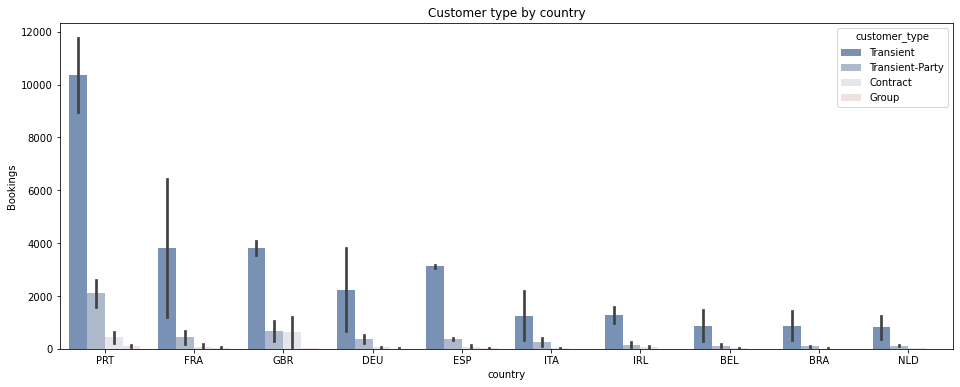

In [32]:
# top country with most bookings by hotel
#aggregate bookings by country
country = df.groupby('country',as_index=False)['is_canceled'].count()

# sort by bookings to get top 15
top_country = country.sort_values(by='is_canceled',ascending=False).head(10)

# filter df for countries in top country
filter = df[df['country'].isin(top_country['country'])]

# aggregate bookings by country and hotel
filter_group = filter.groupby(['country','hotel','customer_type'],as_index=False)['is_canceled'].count()

# sort filter group
filter_group_sort = filter_group.sort_values(by='is_canceled',ascending=False)


# plot graph
plt.figure(figsize=(16,6))
sns.barplot(x='country',y='is_canceled',data=filter_group_sort,hue='customer_type')
plt.ylabel('Bookings')
plt.title('Customer type by country')
sns.set_palette('vlag')

### Most popular room

"The bar chart displays the popularity of reserved room types across the hotels. It clearly shows which room types are most frequently booked, providing insights into guest preferences and potential areas for room upgrades or promotions."

Text(0, 0.5, 'bookings')

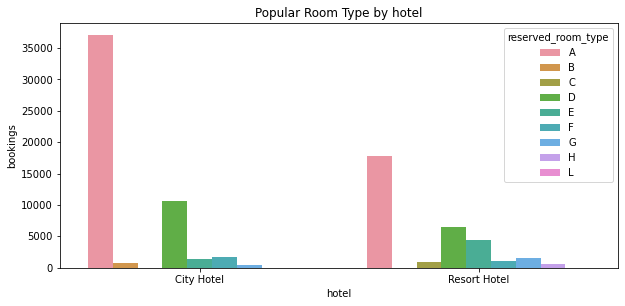

In [40]:
# What is the most commonly reserved room type, and how does it vary between hotels?
# Most popular room by hotel
room = df.groupby(['hotel','reserved_room_type'],as_index=False)['is_canceled'].count()
plt.figure(figsize=(10, 4.5))
sns.barplot(x='hotel',y='is_canceled',data=room,hue='reserved_room_type')
plt.title('Popular Room Type by hotel')
plt.ylabel('bookings')

Text(0, 0.5, 'bookings')

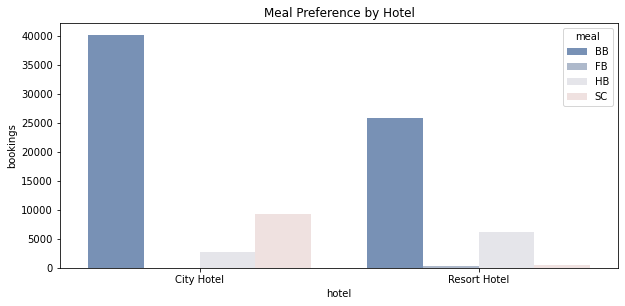

In [41]:
# bar chart showing meal preference
meal = df.groupby(['hotel','meal'],as_index=False)['is_canceled'].count()
plt.figure(figsize=(10, 4.5))
sns.barplot(x='hotel',y='is_canceled',data=meal,hue='meal')
plt.title('Meal Preference by Hotel')
plt.ylabel('bookings')

In [36]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### Length of Stay Distribution
**Figure 5: Distribution of Stay Lengths**
A histogram of stay lengths (Figure 5) shows that the majority of stays are between one and four nights, with a mode at two nights. This distribution is indicative of a trend towards short stays, possibly driven by weekend getaways or short business trips.

![Histogram of Stay Lengths](link-to-chart.png)


Text(0.5, 1.0, 'Distribution of Total Stay')

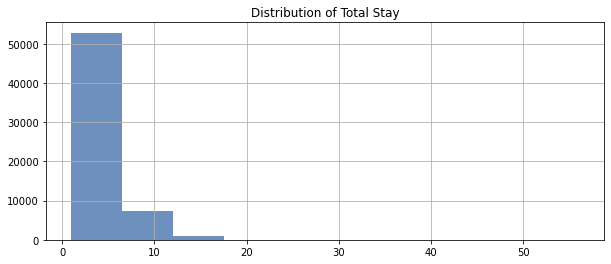

In [43]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Distribution of total stay
stayed = df[df['is_canceled']==0]

plt.figure(figsize=(10,4))
stayed['total_stay'].hist()
plt.title('Distribution of Total Stay')

### Deposit Analysis
##### Get the prorportion of bookings involving a deposit and variations across hotel types

"The bar chart illustrates the proportion of bookings involving a deposit for different types of hotels. It highlights variations in deposit policies between hotel types, suggesting potential strategies for managing financial risks and ensuring revenue stability."

          hotel deposit_type  is_canceled
0    City Hotel   No Deposit        51240
1    City Hotel   Non Refund          843
2    City Hotel   Refundable           15
3  Resort Hotel   No Deposit        32543
4  Resort Hotel   Non Refund          193
5  Resort Hotel   Refundable           92


Text(0.5, 1.0, 'Deposit Types by Hotel')

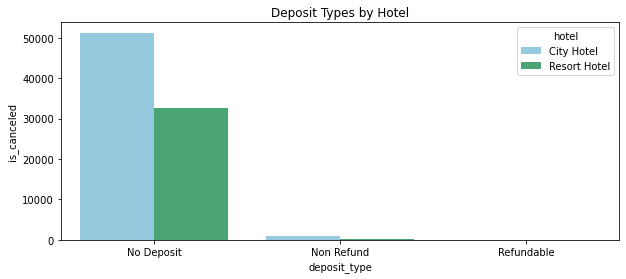

In [42]:
# Analysis of Deposit type by Hotel
# aggregate data
deposit = df.groupby(['hotel','deposit_type'],as_index=False)['is_canceled'].count()
print(deposit)

# plot graph
plt.figure(figsize=(10,4))
sns.barplot(x='deposit_type',y='is_canceled',data=deposit,hue='hotel',palette=palette)
#plt.ylabel("Bookings")
plt.title('Deposit Types by Hotel')

### Adr by customer type

The bar chart compares the average daily rate (ADR) by customer type across different hotels. It clearly demonstrates how ADR varies among customer segments, showing the types of customers that contribute most to revenue more, potentially guiding targeted marketing strategies."


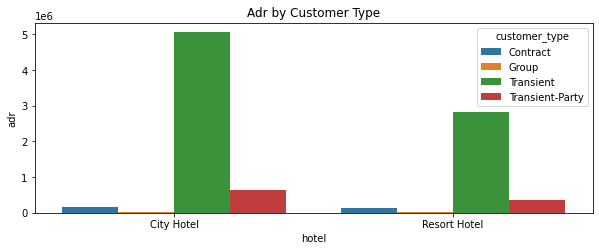

In [4]:
# Adr by customer type 
adr_customer = df.groupby(['hotel','customer_type'],as_index=False)['adr'].sum()
# visualise information
plt.figure(figsize=(10, 3.5))
sns.barplot(x='hotel',y='adr',data=adr_customer,hue='customer_type')
plt.title('Adr by Customer Type')
sns.set_palette('inferno')


### ADR by distribution cahnnel 

"The bar chart illustrates the average daily rate (ADR) distribution by channel for each hotel, highlighting significant differences in pricing strategies and guest acquisition costs across various booking platforms. This visualization can help hotel managers identify the most lucrative channels and optimize their distribution strategies accordingly."

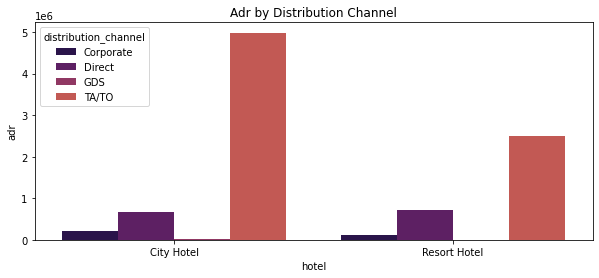

In [47]:

# Adr by distribution channel
# aggregate data
adr_dist = df.groupby(['hotel','distribution_channel'],as_index=False)['adr'].sum()
# visualise information
plt.figure(figsize=(10, 4))
sns.barplot(x='hotel',y='adr',data=adr_dist,hue='distribution_channel')
plt.title('Adr by Distribution Channel')
sns.set_palette('spring')



####  Conclusion of Findings
The analyses conducted reveal clear patterns in booking behavior, cancellation rates, guest demographics, and stay preferences. Seasonal trends indicate the need for targeted operational planning, while the varied preferences across different guest origins and types suggest opportunities for personalized marketing and service offerings. The insights from these findings will guide strategic decisions to enhance guest satisfaction and optimize revenue management.

